In [6]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

import sys 
sys.path.append('../../src')
from tools.dataset import load_well
from models import recipe

In [ ]:
PRIMARY_WELL = 'Activin_GATA6_FoxA2_pos1'
df = load_well(PRIMARY_WELL, mask_channel='Activin')
df.head(3)


,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,...,aspect_ratio,Gata6_mean,Activin_mean,FoxA2_mean,Hoechst_mean,Gata6+,Activin+,FoxA2+,Hoechst+,Activin_bin
cell_id,,,,,,,,,,,,,,,,,,,,,
1,3.841727,287.546763,139.0,47.384776,47.997801,0.860058,0.932886,0.695000,19.010629,9.699167,...,1.960027,144.856115,125.165468,184.165468,1693.208633,False,False,False,True,0.0
2,4.812081,484.248322,149.0,50.870058,50.909356,0.854404,0.897590,0.645022,20.058724,10.422709,...,1.924521,165.093960,124.000000,193.845638,1851.919463,False,False,False,True,0.0
3,4.316832,2989.207921,101.0,36.142136,36.946410,0.710536,0.952830,0.776923,13.665405,9.615813,...,1.421139,137.366337,126.346535,212.415842,1699.257426,False,False,False,True,0.0


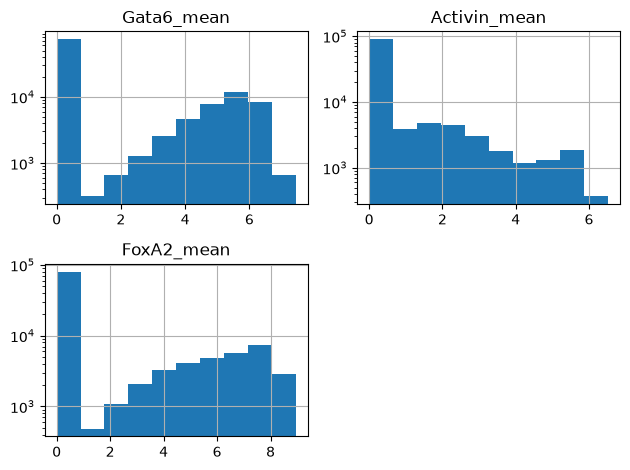

In [12]:
centroids = df[['centroid_y', 'centroid_x']].to_numpy(np.float32)
channels = ['Gata6', 'Activin', 'FoxA2', 'Hoechst']

IF_BACKGROUNDS = {f'{x}': np.percentile(df[f'{x}_mean'], 60) for x in channels[:-1]}
BACKGROUNDS = recipe.normalize(df, [f'{x}_mean' for x in channels[:-1]], backgrounds=IF_BACKGROUNDS)

df[[f'{x}_mean' for x in channels[:-1]]].hist(log=True)
plt.tight_layout()